# NIH Chest XRay - Exploratory Data Analysis
## Objective:
- Explore and describe the dataset (size, classes, missing values, imbalance, correalation)

## Contents:

1. Dataset Overview (size, structure, missing values)
2. Label Distribution (class imbalance)
3. Patient Demographics (age, gender)
4. Image Properties (samples, resolution, pixel intensity)
5. Multi-label Analysis (labels per image, co-occurrence)
6. Dataset Quality Checks (split integrity, patient leakage checks)
7. Visual Inspection (sample X-ray images)
8. Key Findings Summary

## 1. Dataset Overview

This section provides a general overview of the dataset, including its structure, feature types, statistical properties, and missing values.

In [62]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Set dataset paths
dataset_path = '/Volumes/PM961/archive-chest-xrays-nih'
csv_path = os.path.join(dataset_path, "Data_Entry_2017.csv")

In [63]:
# Figure style
#
# One place for the look every figure below shares, so the set reads as one set:
# sized for a ~14 cm thesis text column, no in-figure titles (the caption
# belongs to the document), and a single-hue blue ramp that prints legibly and
# survives greyscale.
from matplotlib.colors import LinearSegmentedColormap

FIG_DIR = "../outputs/eda"
os.makedirs(FIG_DIR, exist_ok=True)

CXR_BLUES = LinearSegmentedColormap.from_list("cxr_blues", [
    "#e9f2fd", "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec",
    "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95",
    "#104281", "#0d366b",
])
CXR_BLUES.set_bad("#f0efec")

# Taken off the ramp, so the flat-colour panels and the heatmaps share a hue.
BLUE = "#2a78d6"
BLUE_LIGHT = "#9ec5f4"
GRID = "#d5d4d0"
INK = "#33322f"

plt.rcParams.update({
    "figure.figsize": (6.0, 3.4),
    "figure.facecolor": "white",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.5,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
})


def style_axes(ax, ygrid=True):
    """Drop the top and right spines and put a light grid behind the data.

    Tick marks are off globally, so the grid is what carries the reader from a
    bar back to the axis.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if ygrid:
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color=GRID, linewidth=0.5, alpha=0.7)


def compact(value, _pos):
    """Axis tick formatter: 20000 -> 20k, 3.5e6 -> 3.5M.

    Keeps one decimal when dropping it would round neighbouring ticks onto the
    same label, which is what a bare "%.0fk" does on any axis whose ticks are
    less than 1000 apart.
    """
    for divisor, suffix in ((1e6, "M"), (1e3, "k")):
        if abs(value) >= divisor:
            scaled = value / divisor
            return f"{scaled:.0f}{suffix}" if scaled == int(scaled) else f"{scaled:.1f}{suffix}"
    return f"{value:,.0f}"


def save_figure(name):
    """Write the current figure into outputs/eda/ at print resolution."""
    plt.savefig(os.path.join(FIG_DIR, name))

In [64]:
# Load the dataset
df = pd.read_csv(csv_path)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [65]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  str    
 1   Finding Labels               112120 non-null  str    
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  str    
 6   View Position                112120 non-null  str    
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), str(4)
memory usage: 10.3 MB


In [66]:
# Statistical summary of numerical columns
df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,0.0
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649,NaN
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


In [67]:
# Check missing values
df.isnull().sum()

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

## 2. Label Distribution

This section analyzes the distribution of labels in the dataset in order to identify class imbalance and the prevalence of different pathologies.

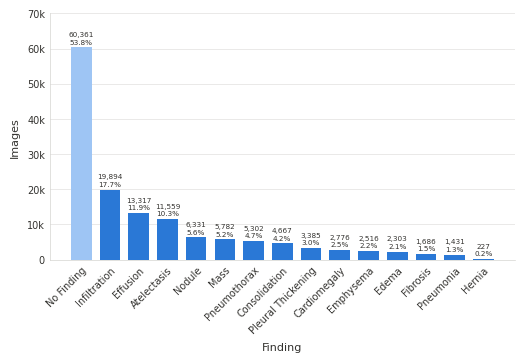

In [68]:
# Count images containing each disease
label_counts = df["Finding Labels"].str.get_dummies(sep="|").sum().sort_values(ascending=False)
total = len(df)

fig, ax = plt.subplots(figsize=(6.0, 3.2))
positions = range(len(label_counts))

# "No Finding" is the majority class and dwarfs every pathology. It stays in the
# figure because this is the label distribution, but it is drawn in the lighter
# tint so the eye reads the pathologies as the subject.
colors = [BLUE_LIGHT if name == "No Finding" else BLUE for name in label_counts.index]
ax.bar(positions, label_counts.values, color=colors, width=0.72)

# Count over share, two lines: at this width that is what fits without the
# labels of adjacent bars colliding.
for i, count in enumerate(label_counts.values):
    ax.text(i, count + total * 0.006, f"{count:,}\n{count / total:.1%}",
            ha="center", va="bottom", fontsize=5.2, color=INK, linespacing=1.3)

ax.set_xticks(positions)
ax.set_xticklabels([name.replace("_", " ") for name in label_counts.index])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlabel("Finding", labelpad=5)
ax.set_ylabel("Images", labelpad=5)
ax.set_ylim(0, label_counts.max() * 1.16)
ax.yaxis.set_major_formatter(compact)
style_axes(ax)

save_figure("disease_presence_distribution.png")
plt.show()

## 3. Patient Demographics

This section examines the demographic characteristics of patients (gender and age).

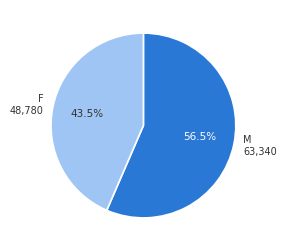

In [69]:
# Gender distribution
gender_counts = df["Patient Gender"].value_counts()

fig, ax = plt.subplots(figsize=(3.0, 3.0))
wedges, _, pct_labels = ax.pie(
    gender_counts.values,
    labels=[f"{name}\n{count:,}" for name, count in gender_counts.items()],
    autopct="%1.1f%%", pctdistance=0.62,
    startangle=90, counterclock=False,
    colors=[BLUE, BLUE_LIGHT],
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
    textprops={"fontsize": 7, "color": INK},
)

# The share sits inside its wedge, so each label takes the colour that stays
# legible against it.
for label, wedge_color in zip(pct_labels, [BLUE, BLUE_LIGHT]):
    label.set_fontsize(7.5)
    label.set_color("white" if wedge_color == BLUE else INK)

ax.set_aspect("equal")
save_figure("gender_distribution.png")
plt.show()

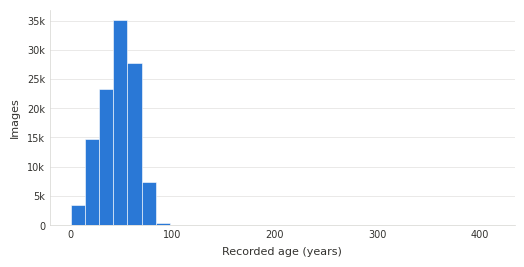

In [70]:
# Age distribution
fig, ax = plt.subplots(figsize=(6.0, 2.8))
ax.hist(df["Patient Age"], bins=30, color=BLUE, edgecolor="white", linewidth=0.4)

ax.set_xlabel("Recorded age (years)", labelpad=5)
ax.set_ylabel("Images", labelpad=5)
ax.yaxis.set_major_formatter(compact)
style_axes(ax)

save_figure("age_distribution_raw.png")
plt.show()

Max recorded age: 414
Records with age > 100: 16
Implausible values: [np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154), np.int64(155), np.int64(411), np.int64(412), np.int64(413), np.int64(414)]
Affected patients: 16


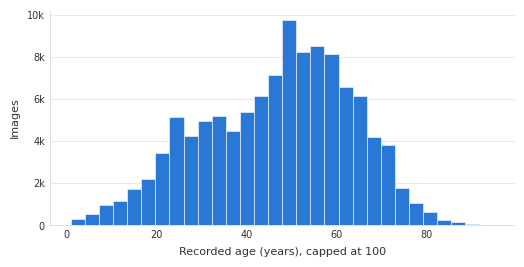

In [71]:
# Data-quality check on 'Patient Age'.
# The NIH release contains a known data-entry error: a handful of records carry
# biologically impossible ages, so the raw histogram above has a misleading tail.
implausible = df[df["Patient Age"] > 100]

print("Max recorded age:", df["Patient Age"].max())
print("Records with age > 100:", len(implausible))
print("Implausible values:", sorted(implausible["Patient Age"].unique()))
print("Affected patients:", implausible["Patient ID"].nunique())

# Same distribution restricted to plausible ages
fig, ax = plt.subplots(figsize=(6.0, 2.8))
ax.hist(df.loc[df["Patient Age"] <= 100, "Patient Age"], bins=30,
        color=BLUE, edgecolor="white", linewidth=0.4)

ax.set_xlabel("Recorded age (years), capped at 100", labelpad=5)
ax.set_ylabel("Images", labelpad=5)
ax.yaxis.set_major_formatter(compact)
style_axes(ax)

save_figure("age_distribution_plausible.png")
plt.show()

## 4. Image Properties

This section explores sample X-ray images and their basic properties, including resolution statistics.

In [72]:
# Build an index of all image folders
image_root = dataset_path
image_dirs = [
    os.path.join(image_root, d)
    for d in os.listdir(image_root)
    if d.startswith("images_")
]

# Create a lookup dictionary (image_name → full path)
image_path_map = {}

for folder in image_dirs:
    img_folder = os.path.join(folder, "images")
    
    if os.path.exists(img_folder):
        for img_name in os.listdir(img_folder):
            image_path_map[img_name] = os.path.join(img_folder, img_name)

In [73]:
# Compute image size statistics (random 5000 images)
widths = []
heights = []

sample_df = df.sample(5000, random_state=42)

for img_name in sample_df["Image Index"]:
    if img_name in image_path_map:
        img = Image.open(image_path_map[img_name])
        
        widths.append(img.size[0])
        heights.append(img.size[1])

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 1024.0
Average height: 1024.0


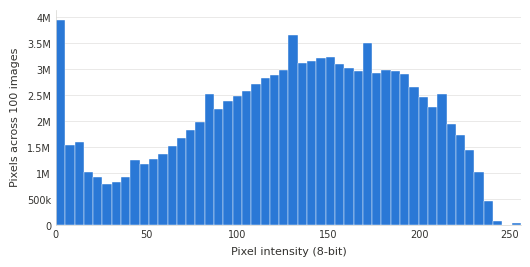

In [74]:
# Pixel intensity distribution (sample of images)
sample_df = df.sample(100, random_state=42)

# Accumulate a histogram per image. Collecting every pixel into a Python list
# would materialise ~100M elements (100 images x 1024x1024) for no extra detail.
bin_edges = np.linspace(0, 256, 51)
counts = np.zeros(len(bin_edges) - 1, dtype=np.int64)

for img_name in sample_df["Image Index"]:
    if img_name in image_path_map:
        with Image.open(image_path_map[img_name]) as img:
            pixels = np.asarray(img.convert("L"))
        counts += np.histogram(pixels, bins=bin_edges)[0]

fig, ax = plt.subplots(figsize=(6.0, 2.8))
ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), align="edge",
       color=BLUE, edgecolor="white", linewidth=0.3)

ax.set_xlabel("Pixel intensity (8-bit)", labelpad=5)
ax.set_ylabel(f"Pixels across {len(sample_df)} images", labelpad=5)
ax.set_xlim(0, 256)
ax.yaxis.set_major_formatter(compact)
style_axes(ax)

save_figure("pixel_intensity_distribution.png")
plt.show()

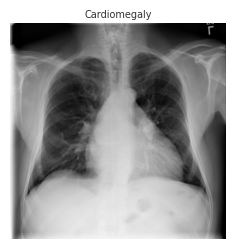

In [75]:
# Display a sample image
sample_image_name = df.iloc[0]["Image Index"]

if sample_image_name in image_path_map:
    img = Image.open(image_path_map[sample_image_name])

    fig, ax = plt.subplots(figsize=(2.8, 2.8))
    ax.imshow(img, cmap="gray")

    # The finding is the point of the panel rather than decoration, so unlike
    # the charts this one keeps its label.
    ax.set_title(df.iloc[0]["Finding Labels"].replace("|", ", "),
                 fontsize=7, color=INK, pad=4)
    ax.axis("off")

    save_figure("sample_image.png")
    plt.show()
else:
    print("Image not found:", sample_image_name)

## 5. Multi-label Analysis

This section analyzes the multi-label structure of the dataset, including the number of labels per image and disease co-occurrence patterns.

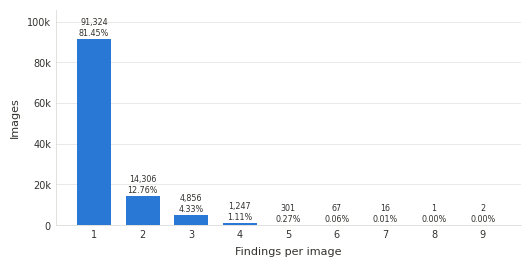

In [76]:
# Number of labels per image
df["label_count"] = df["Finding Labels"].apply(lambda x: len(x.split("|")))
count_by_labels = df["label_count"].value_counts().sort_index()
total = len(df)

fig, ax = plt.subplots(figsize=(6.0, 2.8))
ax.bar(count_by_labels.index, count_by_labels.values, color=BLUE, width=0.7)

for n_labels, count in count_by_labels.items():
    ax.text(n_labels, count + total * 0.006, f"{count:,}\n{count / total:.2%}",
            ha="center", va="bottom", fontsize=5.8, color=INK, linespacing=1.3)

ax.set_xlabel("Findings per image", labelpad=5)
ax.set_ylabel("Images", labelpad=5)
ax.set_xticks(count_by_labels.index)
ax.set_ylim(0, count_by_labels.max() * 1.16)
ax.yaxis.set_major_formatter(compact)
style_axes(ax)

save_figure("number_of_labels_per_image.png")
plt.show()

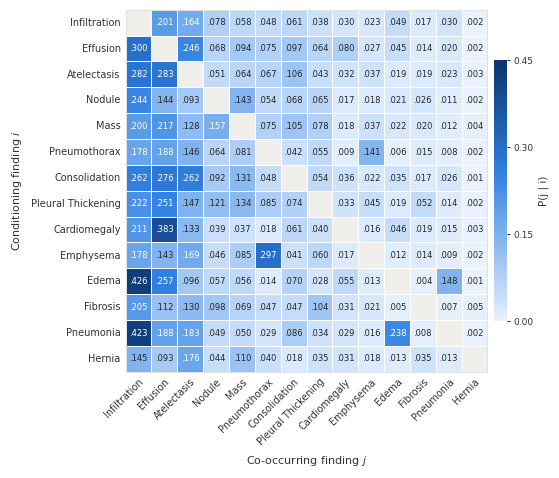

In [77]:
from sklearn.preprocessing import MultiLabelBinarizer

# Convert labels into multi-hot encoding
labels = df["Finding Labels"].apply(lambda x: x.split("|"))

mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(labels)

label_df = pd.DataFrame(label_matrix, columns=mlb.classes_)

# Conditional co-occurrence: P(class j | class i)
Y = label_df.to_numpy()

# Co-occurrence counts and per-class support
co_counts = Y.T @ Y
support = pd.Series(Y.sum(axis=0), index=label_df.columns)

# Conditional probability P(j | i) = count(i and j) / count(i)
cond_matrix = co_counts / np.where(support == 0, 1, support).reshape(-1, 1)
cond_df = pd.DataFrame(cond_matrix, index=label_df.columns, columns=label_df.columns)

# "No Finding" is mutually exclusive with every pathology, so its row and column
# are structurally zero and only cost space on the page.
cond_df = cond_df.drop(index="No Finding", columns="No Finding")
support = support.drop("No Finding")

# Order by prevalence so the frequent findings group together, and drop the
# underscore the NIH release uses in "Pleural_Thickening".
order = support.sort_values(ascending=False).index
cond_df = cond_df.loc[order, order]
cond_df.index = cond_df.columns = [c.replace("_", " ") for c in order]

# P(i | i) = 1 by definition. Masking the diagonal frees the colour scale for
# the off-diagonal range that actually varies.
mask = np.eye(len(cond_df), dtype=bool)
vmax = np.ceil(cond_df.to_numpy()[~mask].max() * 20) / 20

# Three decimals without the leading zero. The rarest off-diagonal pair is
# P(Hernia | Consolidation) = .001, so at this precision no cell rounds away to
# zero and every printed value carries information.
values = cond_df.to_numpy()
annot = np.char.lstrip(np.char.mod("%.3f", values), "0")

# Sized to sit inside a Word text column (~14 cm wide) without dominating the page.
fig, ax = plt.subplots(figsize=(6.0, 4.7))
sns.heatmap(
    cond_df, mask=mask, cmap=CXR_BLUES, vmin=0, vmax=vmax, square=True,
    annot=annot, fmt="", annot_kws={"fontsize": 6},
    linewidths=0.5, linecolor="white", ax=ax,
    cbar_kws={"label": "P(j | i)", "shrink": 0.72, "pad": 0.015,
              "ticks": np.linspace(0, vmax, 4)},
)
# No in-figure title: the caption belongs to the thesis document.
ax.set_xlabel("Co-occurring finding $j$", fontsize=8, labelpad=5)
ax.set_ylabel("Conditioning finding $i$", fontsize=8, labelpad=5)
ax.tick_params(axis="both", labelsize=7, length=0)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=6.5, length=2, pad=2)
cbar.ax.yaxis.label.set_size(7.5)
cbar.outline.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color(GRID)

save_figure("cooccurrence_matrix_conditional.png")
plt.show()

## 6. Dataset Quality Checks

This section validates the correctness of dataset splits and checks for potential data leakage at both file and patient levels.

In [78]:
# Patient uniqueness check
unique_patients = df["Patient ID"].nunique()
total_images = len(df)

print("Unique patients:", unique_patients)
print("Total images:", total_images)

Unique patients: 30805
Total images: 112120


In [79]:
# Split integrity and patient leakage check

# Load split files
with open(os.path.join(dataset_path, "train_val_list.txt"), "r") as f:
    train_files = set(f.read().splitlines())

with open(os.path.join(dataset_path, "test_list.txt"), "r") as f:
    test_files = set(f.read().splitlines())

# File-level split integrity check
file_overlap = train_files.intersection(test_files)

# Create split dataframes
train_df = df[df["Image Index"].isin(train_files)].copy()
test_df = df[df["Image Index"].isin(test_files)].copy()

print("Train images:", len(train_files))
print("Train samples in df:", len(train_df))
print("Test images:", len(test_files))
print("Test samples in df:", len(test_df))
print("File overlap:", len(file_overlap))

# Patient-level leakage check
train_patients = set(train_df["Patient ID"].unique())
test_patients = set(test_df["Patient ID"].unique())
patient_overlap = train_patients.intersection(test_patients)

print("\nTrain patients:", len(train_patients))
print("Test patients:", len(test_patients))
print("Patient overlap:", len(patient_overlap))

Train images: 86524
Train samples in df: 86524
Test images: 25596
Test samples in df: 25596
File overlap: 0

Train patients: 28008
Test patients: 2797
Patient overlap: 0


## 7. Visual Inspection

This section provides a visual inspection of randomly selected chest X-ray images to assess variability in image quality, anatomical structures, and disease presentations.

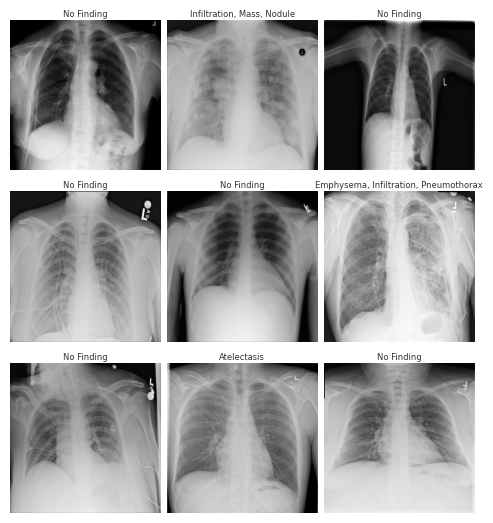

In [80]:
# Visual inspection of random samples
fig, axes = plt.subplots(3, 3, figsize=(6.0, 6.4))
sample_df = df.sample(9, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img_name = sample_df.iloc[i]["Image Index"]

    if img_name in image_path_map:
        img = Image.open(image_path_map[img_name])
        ax.imshow(img, cmap="gray")
        label = sample_df.iloc[i]["Finding Labels"].replace("|", ", ")
    else:
        label = "Missing image"

    ax.set_title(label, fontsize=6, color=INK, pad=3)
    ax.axis("off")

fig.subplots_adjust(wspace=0.04, hspace=0.14)
save_figure("sample_grid.png")
plt.show()

## 8. Key Findings from EDA

- The dataset contains *112,120 images* with *15 unique labels*.
- Most images contain 1–2 labels, confirming *multi-label structure*.
- The dataset is highly imbalanced, with the dominant class being *No Findings (53.84%)*, while *Hernia (0.20%)*, *Pneumonia (1.28%)*, and *Fibrosis (1.50%)* are extremely rare. These classes are strong candidates for class weighting and per-class threshold tuning.
- Significant *co-occurrence* exists between certain diseases. Strong conditional relationships include Edema -> Infiltration, Pneumonia -> Infiltration, Cardiomegaly -> Effusion, and Emphysema -> Pneumothorax. These dependencies should be considered when interpreting per-class errors and setting class-specific thresholds.
- Image resolution varies but is generally consistent.
- No values are missing from the key columns, but `Patient Age` is *not* clean: 16 records carry impossible ages (up to 414), a known data-entry error in the NIH release. Age should be filtered to a plausible range before it is used in any analysis or stratification.
- Train/test filename overlap is zero and patient overlap is zero, which is the expected outcome for clean split integrity.

These findings justify the need for:
- A multi-label classification approach (sigmoid output layer)
- Class imbalance handling techniques
- Standardized preprocessing of images prior to model training